In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df=pd.read_csv(r"C:\Users\patel\Downloads\dirty_financial_transactions.csv")

In [3]:
df.head()

,Transaction_ID,Transaction_Date,Customer_ID,Product_Name,Quantity,Price,Payment_Method,Transaction_Status
0,T0001,2024-08-02,C2205,Headphones,-5.0,$420.21,pay pal,NaN
1,T0002,2020-02-10,C3156,Coffee,469.0,-445.34202525395585,creditcard,Pending
2,T0003,2025-02-30,C2919,Tablet,-4.0,810.9930123946459,credit card,completed
3,T0004,2020-08-17,C3009,Tab,-7.0,868.6083413217348,PayPal,Pending
4,T0005,2025-02-30,C3488,Coffee Machine,-10.0,-763.1224490039416,PayPal,completed


In [4]:
df['Quantity'] = df['Quantity'].abs()

Quantity cannot normally be negative in sales data

In [5]:
df['Price'] = df['Price'].astype(str).str.replace('$','')
df['Price'] = df['Price'].astype(float)
df['Price'] = df['Price'].abs()

also have other isuues like ,Currency symbol $ Negative prices ,Inconsistent formatting which we cleared here

In [6]:
df['Payment_Method'] = df['Payment_Method'].str.lower().str.replace(' ','')

Payment Method are mentioned inconsistently,
Examples:
pay pal & PayPal
creditcard & credit card 

In [7]:
df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'], errors='coerce')

also we have some date issues as 2025-02-30 (February never has 30 days)


In [8]:
df.head(10)

,Transaction_ID,Transaction_Date,Customer_ID,Product_Name,Quantity,Price,Payment_Method,Transaction_Status
0,T0001,2024-08-02,C2205,Headphones,5.0,420.210000,paypal,NaN
1,T0002,2020-02-10,C3156,Coffee,469.0,445.342025,creditcard,Pending
2,T0003,NaT,C2919,Tablet,4.0,810.993012,creditcard,completed
3,T0004,2020-08-17,C3009,Tab,7.0,868.608341,paypal,Pending
4,T0005,NaT,C3488,Coffee Machine,10.0,763.122449,paypal,completed
5,T0006,2021-10-26,C4241,Smartphone,598.0,NaN,paypal,Completed
6,NaN,NaT,C1313,Laptop,10.0,NaN,creditcard,Completed
7,T0008,NaT,C4736,Headphones,669.0,86.921269,cash,NaN
8,T0009,NaT,C3387,Tablet,10.0,461.701984,paypal,NaN
9,T0010,NaT,C2846,Laptop,1.0,404.890707,creditcard,Pending


In [9]:
import warnings

warnings.filterwarnings("ignore")

In [10]:
df['Price'].fillna(df['Price'].mean(), inplace=True)

some rows have missing price. we have replaced them with mean

In [11]:
df['Transaction_Status'] = df['Transaction_Status'].str.upper()

In [12]:
df['Product_Name'] = df['Product_Name'].replace({'Tab':'Tablet'})

In [13]:
df['Price'] = df['Price'].fillna(df['Price'].median())

In [14]:
df['Transaction_Status'] = df['Transaction_Status'].fillna('PENDING')

In [15]:
df = df.dropna(subset=['Transaction_ID'])

In [16]:
df['Transaction_Date'] = df['Transaction_Date'].fillna(df['Transaction_Date'].mode()[0])

convert status to uppercase,fix product name as tab and tablet are same,fill missing price with median,fill missing status,
remove rows where transaction id is missing as if no transaction id we cant track it,filled missing date

In [17]:
df.head(10)

,Transaction_ID,Transaction_Date,Customer_ID,Product_Name,Quantity,Price,Payment_Method,Transaction_Status
0,T0001,2024-08-02,C2205,Headphones,5.0,420.210000,paypal,PENDING
1,T0002,2020-02-10,C3156,Coffee,469.0,445.342025,creditcard,PENDING
2,T0003,2023-10-16,C2919,Tablet,4.0,810.993012,creditcard,COMPLETED
3,T0004,2020-08-17,C3009,Tablet,7.0,868.608341,paypal,PENDING
4,T0005,2023-10-16,C3488,Coffee Machine,10.0,763.122449,paypal,COMPLETED
5,T0006,2021-10-26,C4241,Smartphone,598.0,525.239824,paypal,COMPLETED
7,T0008,2023-10-16,C4736,Headphones,669.0,86.921269,cash,PENDING
8,T0009,2023-10-16,C3387,Tablet,10.0,461.701984,paypal,PENDING
9,T0010,2023-10-16,C2846,Laptop,1.0,404.890707,creditcard,PENDING
10,T0011,2023-10-16,C1004,Laptop,10.0,600.839309,paypal,COMPLETE


In [18]:
df.columns.tolist()

['Transaction_ID',
 'Transaction_Date',
 'Customer_ID',
 'Product_Name',
 'Quantity',
 'Price',
 'Payment_Method',
 'Transaction_Status']

In [19]:
df['Product_Name'] = df['Product_Name'].replace({
    'Lap':'Laptop',
    'La':'Laptop',
    'Smartpho':'Smartphone'
})

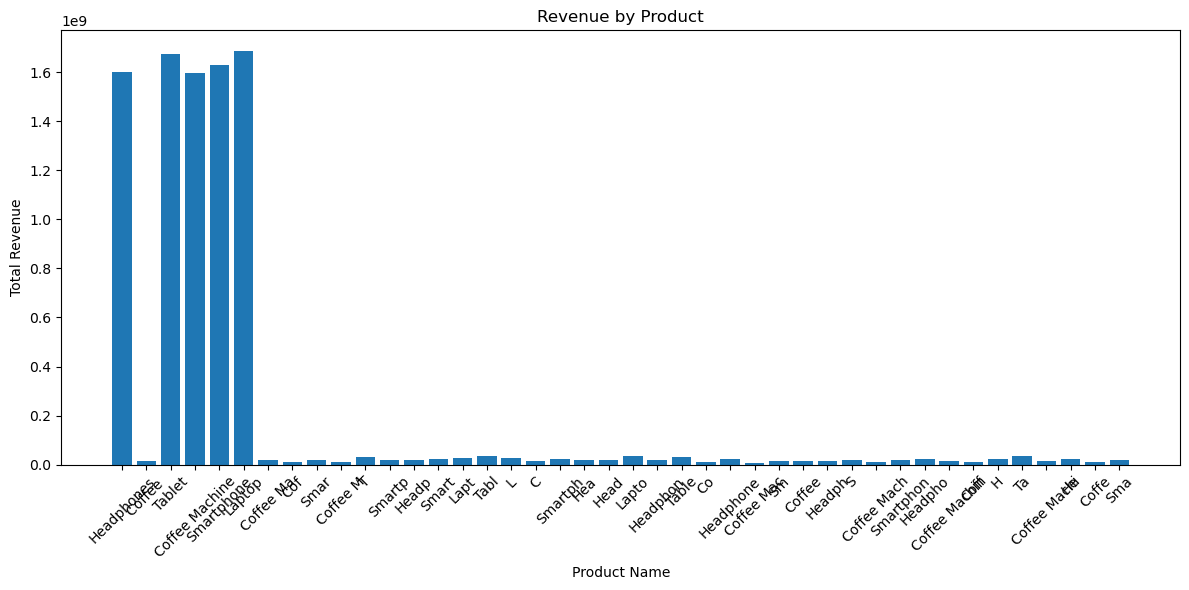

In [20]:

df['Revenue'] = df['Quantity'] * df['Price']

products = df['Product_Name'].unique()

revenues = []

for p in products:
    total_revenue = df[df['Product_Name'] == p]['Revenue'].sum()
    revenues.append(total_revenue)

plt.figure(figsize=(12,6))

plt.bar(products, revenues)

plt.title("Revenue by Product")
plt.xlabel("Product Name")
plt.ylabel("Total Revenue")

plt.xticks(rotation=45)   
plt.tight_layout()       
plt.show()


In [21]:
df.tail()

,Transaction_ID,Transaction_Date,Customer_ID,Product_Name,Quantity,Price,Payment_Method,Transaction_Status,Revenue
99994,T99995,2023-10-16,C2153,Smartphone,741.0,525.239824,paypal,COMPLETE,389202.709331
99996,T99997,2024-08-25,C4830,Smartphone,NaN,503.829517,creditcard,COMPLETED,NaN
99997,T99998,2023-10-16,C280,Laptop,10.0,525.239824,paypal,COMPLETED,5252.398237
99998,T99999,2020-07-12,C4059,Headphones,10.0,525.239824,paypal,COMPLETED,5252.398237
99999,T100000,2023-10-04,C1805,Tablet,2.0,89.374023,paypal,FAILED,178.748047


In [22]:
df.columns = df.columns.str.strip()

df['Customer_ID'] = df['Customer_ID'].fillna('UNKNOWN')
df['Quantity'] = df['Quantity'].fillna(df['Quantity'].median())

df['Transaction_Status'] = df['Transaction_Status'].replace({
    'COMPLETE':'COMPLETED'
})

df['Product_Name'] = df['Product_Name'].replace({
    'Lap':'Laptop',
    'La':'Laptop',
    'Smartpho':'Smartphone',
    'Tabl	':'Tablet'
})

df = df[df['Quantity'] < 100]

df['Revenue'] = df['Quantity'] * df['Price']

data still have many eorrors as names are mentoned differently we have added a column revenue for the further purpose

In [23]:
df.sample(20)

,Transaction_ID,Transaction_Date,Customer_ID,Product_Name,Quantity,Price,Payment_Method,Transaction_Status,Revenue
85754,T85755,2023-10-16,UNKNOWN,Laptop,6.0,84.967519,paypal,COMPLETED,509.805116
91824,T91825,2023-10-16,C4712,Tablet,2.0,525.239824,creditcard,COMPLETED,1050.479647
30850,T30851,2023-10-16,C1190,Tablet,7.0,435.801397,creditcard,COMPLETED,3050.609780
13120,T13121,2023-10-16,C2386,Laptop,5.0,581.710118,paypal,PENDING,2908.550592
947,T0948,2023-10-16,C358,Laptop,9.0,340.492636,creditcard,COMPLETED,3064.433726
31314,T9526,2023-10-16,C2770,Laptop,1.0,255.142470,paypal,COMPLETED,255.142470
75890,T75891,2023-10-16,C4264,Tablet,1.0,820.727542,paypal,COMPLETED,820.727542
84541,T84542,2023-10-16,C4797,Headphones,6.0,636.818779,paypal,COMPLETED,3820.912676
17333,T17334,2023-10-16,C557,Laptop,5.0,525.239824,creditcard,COMPLETED,2626.199118
510,T0511,2023-10-16,C4419,Coffee Machine,8.0,525.239824,creditcard,COMPLETED,4201.918589


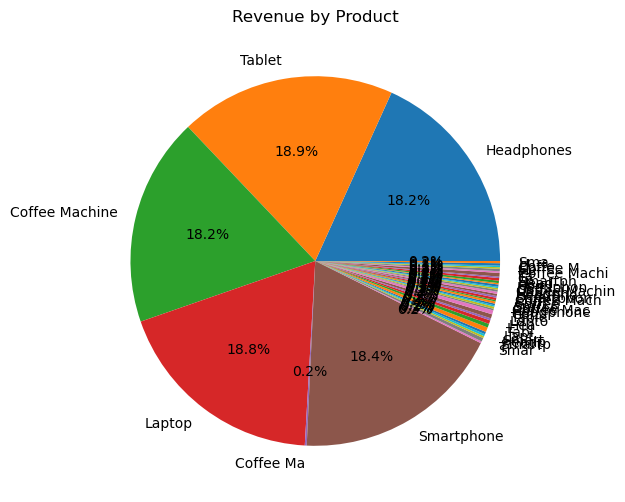

In [24]:
df['Revenue'] = df['Quantity'] * df['Price']
products = df['Product_Name'].unique()
revenues = []

for p in products:
    total_revenue = df[df['Product_Name'] == p]['Revenue'].sum()
    revenues.append(total_revenue)

plt.figure(figsize=(6,6))
plt.pie(revenues, labels=products, autopct='%1.1f%%')
plt.title("Revenue by Product")
plt.show()

In [25]:
df.columns

Index(['Transaction_ID', 'Transaction_Date', 'Customer_ID', 'Product_Name',
       'Quantity', 'Price', 'Payment_Method', 'Transaction_Status', 'Revenue'],
      dtype='object')

In [26]:
df['Product_Name'].unique()

array(['Headphones', 'Tablet', 'Coffee Machine', 'Laptop', 'Coffee Ma',
       'Smartphone', 'Smar', 'T', 'Smartp', 'Headp', 'Smart', 'Lapt',
       'Tabl', 'L', 'Hea', 'Lapto', 'Table', 'Cof', 'Headphone',
       'Coffee Mac', 'Coffee ', 'Sm', 'Coffee', 'S', 'Coffee Mach',
       'Smartphon', 'Headpho', 'Headph', 'Coffee Machin', 'Coff',
       'Headphon', 'Co', 'Head', 'Smartph', 'C', 'Ta', 'Coffee Machi',
       'He', 'Coffee M', 'Coffe', 'H', 'Sma'], dtype=object)

In [27]:
df['Payment_Method']

0            paypal
2        creditcard
3            paypal
4            paypal
8            paypal
            ...    
99992    creditcard
99996    creditcard
99997        paypal
99998        paypal
99999        paypal
Name: Payment_Method, Length: 64649, dtype: object

In [28]:
df['Product_Name'] = df['Product_Name'].str.lower()

df.loc[df['Product_Name'].str.contains('lap'), 'Product_Name'] = 'Laptop'
df.loc[df['Product_Name'].str.contains('smart'), 'Product_Name'] = 'Smartphone'
df.loc[df['Product_Name'].str.contains('head'), 'Product_Name'] = 'Headphones'
df.loc[df['Product_Name'].str.contains('tab'), 'Product_Name'] = 'Tablet'
df.loc[df['Product_Name'].str.contains('cof'), 'Product_Name'] = 'Coffee Machine'

In [29]:
df['Product_Name'].unique()

array(['Headphones', 'Tablet', 'Coffee Machine', 'Laptop', 'Smartphone',
       'smar', 't', 'l', 'hea', 'sm', 's', 'co', 'c', 'ta', 'he', 'h',
       'sma'], dtype=object)

In [30]:
df['Product_Name'] = df['Product_Name'].str.lower()

df.loc[df['Product_Name'].str.contains('lap|^l$'), 'Product_Name'] = 'Laptop'
df.loc[df['Product_Name'].str.contains('smart|sm|^s$'), 'Product_Name'] = 'Smartphone'
df.loc[df['Product_Name'].str.contains('head|he|^h$'), 'Product_Name'] = 'Headphones'
df.loc[df['Product_Name'].str.contains('tab|^t$'), 'Product_Name'] = 'Tablet'
df.loc[df['Product_Name'].str.contains('cof|co|^c$'), 'Product_Name'] = 'Coffee Machine'

In [31]:
df['Product_Name'].unique()

array(['Headphones', 'Tablet', 'Coffee Machine', 'Laptop', 'Smartphone',
       'ta'], dtype=object)

In [32]:
df['Product_Name'] = df['Product_Name'].replace({'ta':'Tablet'})


column product_name is partially cleaned but still contains broken product 
names we have Cleaned the Product_Name column completely

In [33]:
df['Product_Name'].unique()

array(['Headphones', 'Tablet', 'Coffee Machine', 'Laptop', 'Smartphone'],
      dtype=object)

# Revenue by Product

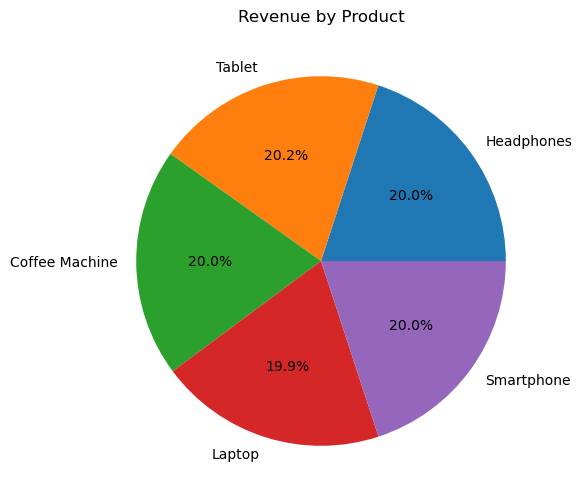

In [34]:
df['Revenue'] = df['Quantity'] * df['Price']
products = df['Product_Name'].unique()
revenues = []

for p in products:
    total_revenue = df[df['Product_Name'] == p]['Revenue'].sum()
    revenues.append(total_revenue)

plt.figure(figsize=(6,6))
plt.pie(revenues, labels=products, autopct='%1.1f%%')
plt.title("Revenue by Product")
plt.show()

Revenue is almost evenly distributedRevenue is almost evenly distributed
Tablet has the highest revenue compared to other products
Headphones and Coffee Machine have slightly lower shares
NOsingle product is dominating the market
Business Insight

From this chart we can infer:

The product portfolio is balanced

Marketing can focus on boosting weaker categories

Inventory planning should support all products equally

# Product Sales By Quantity

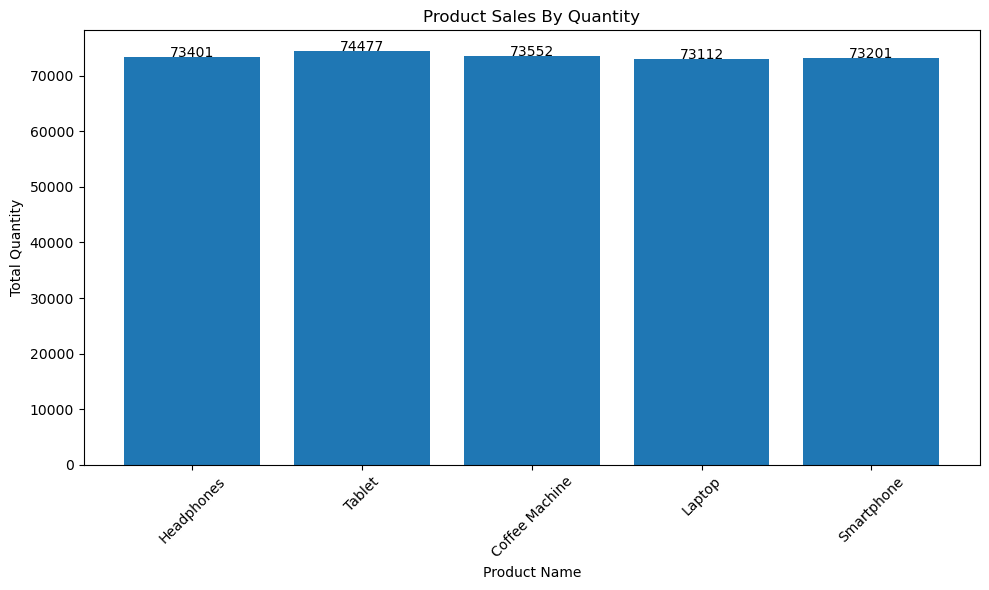

In [35]:
products = df['Product_Name'].unique()

revenues = []
for p in products:
    total_revenue = df[df['Product_Name'] == p]['Quantity'].sum()
    revenues.append(total_revenue)

plt.figure(figsize=(10,6))

bars = plt.bar(products, revenues)
for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height(), int(bar.get_height()), ha='center')

plt.title("Product Sales By Quantity")
plt.xlabel("Product Name")
plt.ylabel("Total Quantity")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The bar chart illustrates the total quantity sold for each product category. By comparing the bar heights, we can identify which products are the most and least popular among customers. This information can help the business focus marketing efforts on high-demand products and evaluate strategies for improving sales of lower-performing products.

# Demand Distribution of product

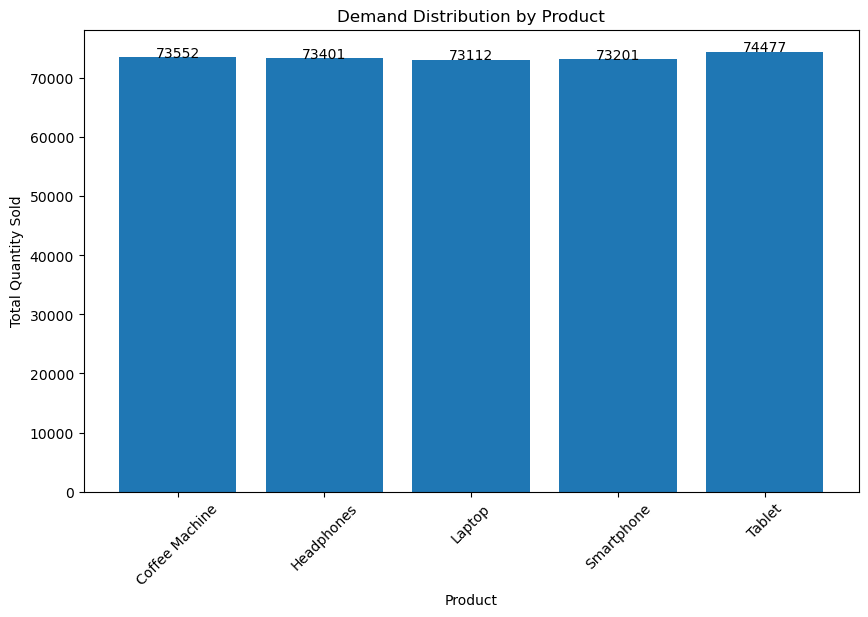

In [36]:
plt.close()

demand = df.groupby('Product_Name')['Quantity'].sum()

plt.figure(figsize=(10,6))
bars = plt.bar(demand.index, demand.values)

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             int(bar.get_height()),
             ha='center')

plt.title("Demand Distribution by Product")
plt.xlabel("Product")
plt.ylabel("Total Quantity Sold")

plt.xticks(rotation=45)
plt.show()

The demand distribution chart shows how product demand varies across categories. Products with higher bars i.e coffe machine represent stronger customer demand, while lower bars indicate products that are purchased less frequently. This visualization helps identify top-selling and underperforming products.